# Testing of different hive dimensions for Hive objets across different datasets

## Imports

In [1]:
import sys, cv2
sys.path.append('RHCImaging')
from libvisu import Hive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from RHCImaging.libimage import fetchImagesPaths

## Config

In [2]:
hive_nb = 1
dt = pd.Timestamp(2024, 12, 8, 14).tz_localize('UTC')
print(f"Loading hive {hive_nb} at {dt}")
rootpath_imgs = '/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/24.11-25.01_metabolism_OH/Images/'
verbose = False

Loading hive 1 at 2024-12-08 14:00:00+00:00


## Main code

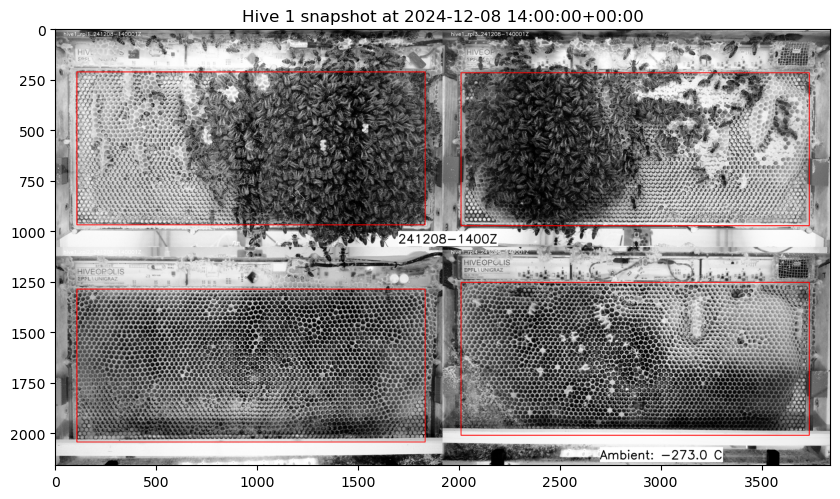

In [3]:
img_paths = fetchImagesPaths(rootpath_imgs, [dt], hive_nb, verbose=verbose)
image_names = img_paths.iloc[0].to_list()
image_names = [img_path.split('/')[-1][:-4] for img_path in image_names]
images = [cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) for img_path in img_paths.iloc[0].to_list()]
hive = Hive(dt, images, False, image_names, hive_nb=hive_nb)

snapshot = hive.snapshot(show_frame_border=True)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(snapshot, cmap='gray')
ax.set_title(f"Hive {hive_nb} snapshot at {dt}")
plt.show()

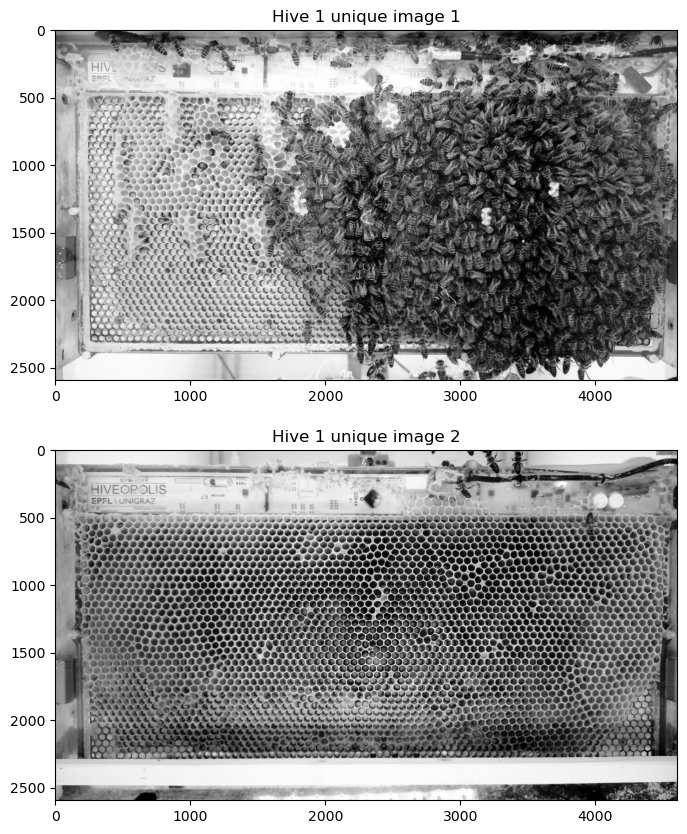

In [4]:
unique_imgs =hive.getUniqueRPiImages()
# Plot the first two unique images on top of each other in a two-row subplot
fig, ax = plt.subplots(2, 1, figsize=(20, 10))
ax[0].imshow(unique_imgs[0], cmap='gray')
ax[0].set_title(f"Hive {hive_nb} unique image 1")
ax[1].imshow(unique_imgs[1], cmap='gray')
ax[1].set_title(f"Hive {hive_nb} unique image 2")
plt.show()